In [1]:
# Paso 1. Cargar y preparar el dataset+
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Cargar el dataset Titanic desde seaborn
titanic = sns.load_dataset("titanic")

# Seleccionar variables relevantes o Independientes
cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = titanic[cols].dropna()  # eliminar valores nulos

# Convertir variables categóricas a numéricas mediante One-Hot Encoding
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# Mostrar las primeras filas
print(df.head())

   survived  pclass   age  sibsp  parch     fare  sex_male  embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [2]:
#Paso 2. Separar variables predictoras y etiqueta
# Variable objetivo (target)
y = df['survived']

# Variables predictoras (features)
X = df.drop(columns='survived')

# Mostrar dimensiones
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (712, 8)
Tamaño de y: (712,)


In [3]:
# Paso 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (498, 8)
Datos de prueba: (214, 8)


In [4]:
# Paso 4. Entrenar el modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear el modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=110,     # número de árboles
    max_depth=5,          # profundidad máxima
    random_state=42
)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo_rf.predict(X_test)

# Evaluar desempeño
print("Precisión del modelo (accuracy):", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))

Precisión del modelo (accuracy): 0.780373831775701

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       122
           1       0.80      0.65      0.72        92

    accuracy                           0.78       214
   macro avg       0.78      0.76      0.77       214
weighted avg       0.78      0.78      0.78       214


Matriz de confusión:
 [[107  15]
 [ 32  60]]


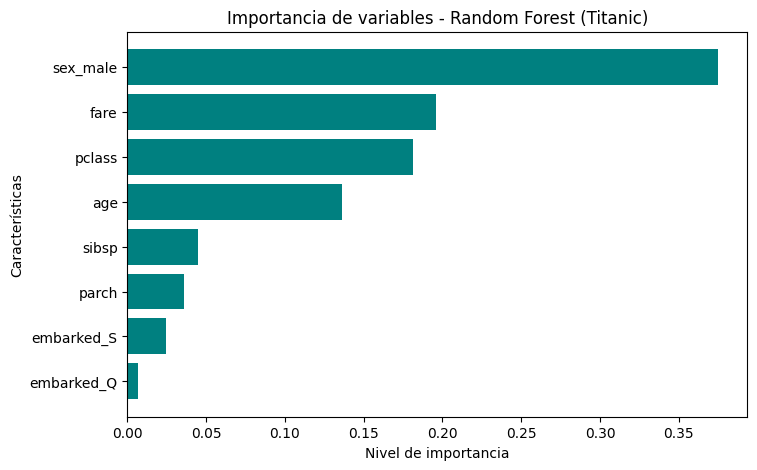

In [5]:
# Paso 5. Importancia de las variables
import matplotlib.pyplot as plt
import numpy as np

# Obtener importancia de características
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importancias[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Importancia de variables - Random Forest (Titanic)")
plt.xlabel("Nivel de importancia")
plt.ylabel("Características")
plt.show()

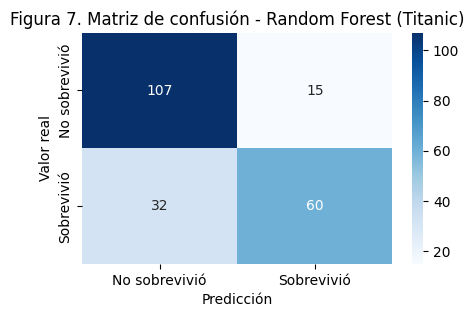

Exactitud global del modelo: 78.04%


In [6]:
# Paso 1. Matriz de confusión
# Librerías necesarias
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.title("Figura 7. Matriz de confusión - Random Forest (Titanic)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Calcular accuracy global
acc = accuracy_score(y_test, y_pred)
print(f"Exactitud global del modelo: {acc:.2%}")

In [7]:
# Paso 2. Reporte de métricas
# Reporte detallado
print("Figura 8. Reporte de clasificación\n")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

Figura 8. Reporte de clasificación

               precision    recall  f1-score   support

No sobrevivió       0.77      0.88      0.82       122
   Sobrevivió       0.80      0.65      0.72        92

     accuracy                           0.78       214
    macro avg       0.78      0.76      0.77       214
 weighted avg       0.78      0.78      0.78       214



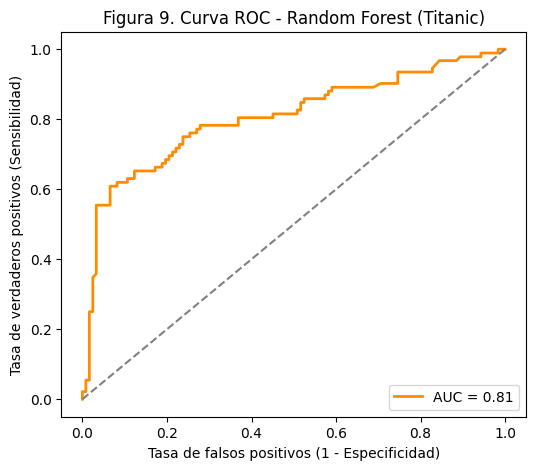

In [9]:
# Código de evaluación de regresión
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Cargar datos
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo
modelo_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
modelo_reg.fit(X_train, y_train)

# Predicciones
y_pred = modelo_reg.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 42.18
RMSE: 52.62
R²: 0.49
